In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
#loading the dataset
df= pd.read_csv("customer_data.csv")
print(df.head())

   CustomerID  Age  Annual Income (k$)  Spending Score  Online Purchase Count
0           1   22                  15              39                      5
1           2   35                  25              81                     12
2           3   29                  19               6                      3
3           4   45                  45              77                     15
4           5   31                  40              40                      9


In [7]:
#data preprocessing
data = df.drop('CustomerID', axis=1)  # Dropping non-numeric column
data


,Age,Annual Income (k$),Spending Score,Online Purchase Count
0,22,15,39,5
1,35,25,81,12
2,29,19,6,3
3,45,45,77,15
4,31,40,40,9
5,50,65,75,20
6,23,20,30,4
7,40,70,60,18
8,33,22,82,11
9,48,63,72,17


In [9]:
#standardize features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print("Standardization complete")


Standardization complete


In [ ]:
#applying pca(2 components)
pca =PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
print('PCA result(First 5 rows):')
print(pca_df.head())

PCA result(First 5 rows):
        PC1       PC2
0 -2.406358  0.380752
1  0.056346  1.388063
2 -2.799648 -1.117393
3  1.293914  0.474639
4 -0.898275 -0.458848


In [12]:
print('Experienced Variance Ratio of each PCA:',pca.explained_variance_ratio_)

Experienced Variance Ratio of each PCA: [0.88010665 0.09508319]


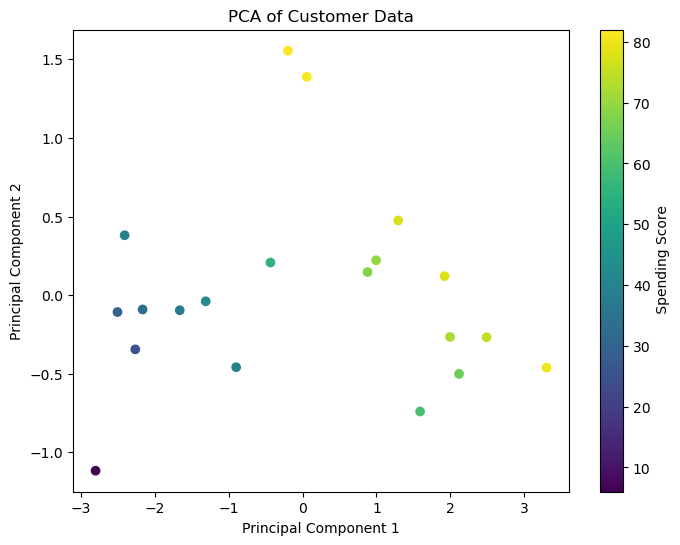

In [16]:
#visualization
plt.figure(figsize=(8,6))
scatter = plt.scatter( pca_df['PC1'], pca_df['PC2'], c=df['Spending Score'],cmap='viridis')
plt.colorbar(scatter,  label=' Spending Score')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Customer Data')
plt.show()


In [17]:
#merging PCA results with original data
final_df = pd.concat([df, pca_df], axis=1)
print('Final DataFrame with PCA components:')
print(final_df.head())

Final DataFrame with PCA components:
   CustomerID  Age  ...       PC1       PC2
0           1   22  ... -2.406358  0.380752
1           2   35  ...  0.056346  1.388063
2           3   29  ... -2.799648 -1.117393
3           4   45  ...  1.293914  0.474639
4           5   31  ... -0.898275 -0.458848

[5 rows x 7 columns]


In [18]:
print('\n Insights Report')
print('1. PCA1 Explains {:.2f}% of the variance.'.format(pca.explained_variance_ratio_[0]*100))
print('2. PCA2 Explains {:.2f}% of the variance.'.format(pca.explained_variance_ratio_[1]*100))



 Insights Report
1. PCA1 Explains 88.01% of the variance.
2. PCA2 Explains 9.51% of the variance.


In [ ]:
#CUSTOMER segmentation using unsupervised learning(kmeand)
